In [1]:
import pandas as pd
import numpy as np
from scipy.sparse.linalg import factorized, svds
from scipy.sparse import coo_array, coo_matrix, csc_matrix, eye_array, linalg
from src.recovery_model import RecoveryModel
from scipy.sparse.csgraph import maximum_flow
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("multi_sparse", False)
pd.set_option("display.float_format", "{:.2f}".format)

$$AX = Y \Rightarrow X = A^{-1}Y$$

let's have: $A = P^T$

$$\begin{matrix} X = A^{-1}Y &\Rightarrow X = (P^T)^{-1}Y \\ &\Rightarrow X = (P^{-1})^TY \end{matrix}$$


$$
\begin{aligned}
(F_1, P_1, C_1, \varnothing, \varnothing) &= 0.25 \times (F_1, P_1, \varnothing, \varnothing, \varnothing) \\
(F_1, P_1, C_1, M_1, \varnothing) &= 0.52 \times (F_1, P_1, C_1, \varnothing, \varnothing) \\
(F_1, P_1, C_1, M_2, \varnothing) &= 0.48 \times (F_1, P_1, C_1, \varnothing, \varnothing) \\
(F_1, P_1, C_1, M_1, E_1) &= 0.70 \times (F_1, P_1, C_1, M_1, \varnothing) \\
(F_1, P_1, C_1, M_1, E_2) &= 0.30 \times (F_1, P_1, C_1, M_1, \varnothing) \\
(F_1, P_1, C_1, M_2, E_1) &= 0.98 \times (F_1, P_1, C_1, M_2, \varnothing) \\
(F_1, P_1, C_1, M_2, E_2) &= 0.02 \times (F_1, P_1, C_1, M_2, \varnothing) \\
(F_1, P_1, C_2, \varnothing, \varnothing) &= 0.59 \times (F_1, P_1, \varnothing, \varnothing, \varnothing)
\end{aligned}
$$


In [2]:
# Select a folder for the data to be used
folder = "test_2"  # test_1  test_2  Toy_WEEE_v2
layer_0 = "flow"
layer_1 = "product"
layer_2 = "component"
layer_3 = "material"
layer_4 = "element"

In [3]:
layer_names = (layer_0, layer_1, layer_2, layer_3, layer_4)
all_symbols = {layer_1: "P*", layer_2: "C*", layer_3: "M*", layer_4: "E*"}

metadata = {
    "path": f"data/{folder}/",
    "filename": "metadata.csv",
}
composition = {
    "path": f"data/{folder}/",
    "filename": "composition.csv",
    "mapper": {
        "Stock/Flow ID": layer_0,
        "Layer 1": layer_1,
        "Layer 2": layer_2,
        "Layer 3": layer_3,
        "Layer 4": layer_4,
        "Value": "data",
        "Year": "year",
        "Scenario": "scenario",
        "Location": "region",
        "parameterCode": "parameterCode",
        "UoM": "unit",
    },
    "parameterCode": {
        layer_2: "c-p",
        layer_3: "m-c",
        layer_4: "e-m",
    },
}

inputs = {
    "path": f"data/{folder}/",
    "filename": "inputs.csv",
    "mapper": {
        "Stock/Flow ID": layer_0,
        "Substance_main_parent": layer_1,
        "Value": "data",
        "Year": "year",
        "Unit": "unit",
    },
}

tcs = {
    "path": f"data/{folder}/",
    "filename": "TCs.csv",
    "mapper": {
        # inflows / outflows
        "input_flow": "inflows",
        "output_flow": "outflows",
        # levels
        "input_layer": "input_layer1_level",
        "input_sub_layer": "input_layer2_level",
        "output_layer": "output_layer1_level",
        # keys
        "input_layer_key": "input_layer1_key",
        "input_sub_layer_key": "input_layer2_key",
        "output_target_key": "output_layer1_key",
        # other columns
        "value": "data",
        "Year": "year",
        "process": "process",
    },
    "all_symbols": {
        layer_1: "P*",
        layer_2: "C*",
        layer_3: "M*",
        layer_4: "E*",
    },
}

In [4]:
model = RecoveryModel(
    name=folder,
    metadata=metadata,
    composition=composition,
    inputs=inputs,
    tcs=tcs,
    layer_names=layer_names,
    save_intermediary_steps=False,
    save_duplicates=False,
)

In [5]:
model.nnz_idx

array([ 36,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
        57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
        70,  71,  72,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 153, 154, 155, 156, 157, 158, 159,
       160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 189, 190,
       191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203,
       204, 205, 206, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243,
       244, 245, 246, 247, 248, 249, 250, 251, 270, 271, 272, 273, 274,
       275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287,
       306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318,
       319, 320, 321, 322, 323, 342, 343, 344, 345, 346, 347, 348, 349,
       350, 378, 379, 380, 381, 382, 383, 384, 385, 386, 414, 41

In [6]:
sorted_loc = np.argsort(model.nnz_idx)
sorted_nnz_idx = model.nnz_idx[sorted_loc]

In [7]:
model.rows

array([ 45,  54,  63,  81,  90,  99,  48,  51,  57,  60,  66,  69,  84,
        87,  93,  96, 102, 105,  49,  50,  52,  53,  58,  59,  61,  62,
        67,  68,  70,  71,  85,  86,  88,  89,  94,  95,  97,  98, 103,
       104, 106, 107, 160, 158, 157, 156, 155, 154, 153, 159, 161, 169,
       163, 170, 164, 168, 165, 166, 167, 162, 197, 195, 194, 193, 192,
       196, 191, 190, 189, 206, 201, 205, 204, 203, 202, 199, 198, 200,
       277, 278, 276, 275, 274, 273, 272, 270, 271, 287, 279, 280, 281,
       282, 283, 284, 285, 286, 308, 313, 309, 310, 311, 312, 314, 306,
       307, 316, 318, 323, 322, 320, 319, 317, 315, 321, 205, 166, 199,
       198, 170, 169, 168, 167, 204, 206, 165, 164, 203, 201, 162, 126,
       128, 129, 130, 127, 202, 132, 133, 134, 163, 200, 131, 270, 312,
       311, 310, 309, 239, 308, 271, 276, 273, 274, 275, 278, 306, 307,
       313, 277, 272, 314, 238, 240, 242, 241, 234, 235, 236, 237, 244,
       280, 281, 319, 243, 323, 287, 315, 316, 317, 318, 279, 25

In [8]:
rows_idx = sorted_loc[np.searchsorted(sorted_nnz_idx, model.rows)]
rows_idx

array([  1,  10,  19,  29,  38,  47,   4,   7,  13,  16,  22,  25,  32,
        35,  41,  44,  50,  53,   5,   6,   8,   9,  14,  15,  17,  18,
        23,  24,  26,  27,  33,  34,  36,  37,  42,  43,  45,  46,  51,
        52,  54,  55,  78,  76,  75,  74,  73,  72,  71,  77,  79,  87,
        81,  88,  82,  86,  83,  84,  85,  80,  97,  95,  94,  93,  92,
        96,  91,  90,  89, 106, 101, 105, 104, 103, 102,  99,  98, 100,
       132, 133, 131, 130, 129, 128, 127, 125, 126, 142, 134, 135, 136,
       137, 138, 139, 140, 141, 145, 150, 146, 147, 148, 149, 151, 143,
       144, 153, 155, 160, 159, 157, 156, 154, 152, 158, 105,  84,  99,
        98,  88,  87,  86,  85, 104, 106,  83,  82, 103, 101,  80,  62,
        64,  65,  66,  63, 102,  68,  69,  70,  81, 100,  67, 125, 149,
       148, 147, 146, 112, 145, 126, 131, 128, 129, 130, 133, 143, 144,
       150, 132, 127, 151, 111, 113, 115, 114, 107, 108, 109, 110, 117,
       135, 136, 156, 116, 160, 142, 152, 153, 154, 155, 134, 12

In [9]:
sorted_nnz_idx[rows_idx]

array([ 45,  54,  63,  81,  90,  99,  48,  51,  57,  60,  66,  69,  84,
        87,  93,  96, 102, 105,  49,  50,  52,  53,  58,  59,  61,  62,
        67,  68,  70,  71,  85,  86,  88,  89,  94,  95,  97,  98, 103,
       104, 106, 107, 160, 158, 157, 156, 155, 154, 153, 159, 161, 169,
       163, 170, 164, 168, 165, 166, 167, 162, 197, 195, 194, 193, 192,
       196, 191, 190, 189, 206, 201, 205, 204, 203, 202, 199, 198, 200,
       277, 278, 276, 275, 274, 273, 272, 270, 271, 287, 279, 280, 281,
       282, 283, 284, 285, 286, 308, 313, 309, 310, 311, 312, 314, 306,
       307, 316, 318, 323, 322, 320, 319, 317, 315, 321, 205, 166, 199,
       198, 170, 169, 168, 167, 204, 206, 165, 164, 203, 201, 162, 126,
       128, 129, 130, 127, 202, 132, 133, 134, 163, 200, 131, 270, 312,
       311, 310, 309, 239, 308, 271, 276, 273, 274, 275, 278, 306, 307,
       313, 277, 272, 314, 238, 240, 242, 241, 234, 235, 236, 237, 244,
       280, 281, 319, 243, 323, 287, 315, 316, 317, 318, 279, 25

In [10]:
cols_idx = sorted_loc[np.searchsorted(sorted_nnz_idx, model.cols)]
input_rows_idx = sorted_loc[np.searchsorted(sorted_nnz_idx, model.input_rows)]

In [11]:
np.array(
    [
        [min(rows_idx), max(rows_idx)],
        [min(model.rows), max(model.rows)],
        [min(cols_idx), max(cols_idx)],
        [min(model.cols), max(model.cols)],
        [min(input_rows_idx), max(input_rows_idx)],
        [min(model.input_rows), max(model.input_rows)],
    ]
)

array([[  1, 361],
       [ 45, 863],
       [  0, 337],
       [ 36, 755],
       [  0,  28],
       [ 36,  72]])

In [12]:
lneqs = coo_matrix(
    (model.data, (rows_idx, cols_idx)),
    shape=(model.real_size, model.real_size),
).tocsc()
lneqs

<362x362 sparse matrix of type '<class 'numpy.float64'>'
	with 441 stored elements in Compressed Sparse Column format>

In [13]:
model.lneqs

<864x864 sparse matrix of type '<class 'numpy.float64'>'
	with 441 stored elements in Compressed Sparse Row format>

In [14]:
Y = coo_array(
    (model.input_data, (input_rows_idx, np.zeros_like(input_rows_idx))),
    shape=(model.real_size, 1),
).tocsc()
Y

<362x1 sparse array of type '<class 'numpy.int64'>'
	with 2 stored elements in Compressed Sparse Column format>

In [15]:
model.y

<864x1 sparse array of type '<class 'numpy.int64'>'
	with 2 stored elements in Compressed Sparse Column format>

In [16]:
new_sol = linalg.spsolve(eye_array(model.real_size) - lneqs, Y)
new_sol

array([1.00000000e+03, 2.50000000e+02, 0.00000000e+00, 0.00000000e+00,
       1.30000000e+02, 9.10000000e+01, 3.90000000e+01, 1.20000000e+02,
       1.17600000e+02, 2.40000000e+00, 5.90000000e+02, 0.00000000e+00,
       0.00000000e+00, 3.89400000e+02, 1.09032000e+02, 2.80368000e+02,
       2.00600000e+02, 1.60480000e+01, 1.84552000e+02, 1.60000000e+02,
       0.00000000e+00, 0.00000000e+00, 7.84000000e+01, 2.50880000e+01,
       5.33120000e+01, 8.16000000e+01, 1.46880000e+01, 6.69120000e+01,
       7.00000000e+02, 3.01000000e+02, 0.00000000e+00, 0.00000000e+00,
       1.56520000e+02, 4.06952000e+01, 1.15824800e+02, 1.44480000e+02,
       8.81328000e+01, 5.63472000e+01, 4.90000000e+01, 0.00000000e+00,
       0.00000000e+00, 4.36100000e+01, 2.00606000e+01, 2.35494000e+01,
       5.39000000e+00, 2.69500000e+00, 2.69500000e+00, 3.50000000e+02,
       0.00000000e+00, 0.00000000e+00, 1.22500000e+02, 8.57500000e+01,
       3.67500000e+01, 2.27500000e+02, 6.59750000e+01, 1.61525000e+02,
      

In [17]:
original_sol = linalg.spsolve(eye_array(model.size) - model.lneqs, model.y)
original_sol

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.00000000e+03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 2.50000000e+02, 0.00000000e+00, 0.00000000e+00,
       1.30000000e+02, 9.10000000e+01, 3.90000000e+01, 1.20000000e+02,
       1.17600000e+02, 2.40000000e+00, 5.90000000e+02, 0.00000000e+00,
      

In [18]:
original_sol[sorted_nnz_idx]

array([1.00000000e+03, 2.50000000e+02, 0.00000000e+00, 0.00000000e+00,
       1.30000000e+02, 9.10000000e+01, 3.90000000e+01, 1.20000000e+02,
       1.17600000e+02, 2.40000000e+00, 5.90000000e+02, 0.00000000e+00,
       0.00000000e+00, 3.89400000e+02, 1.09032000e+02, 2.80368000e+02,
       2.00600000e+02, 1.60480000e+01, 1.84552000e+02, 1.60000000e+02,
       0.00000000e+00, 0.00000000e+00, 7.84000000e+01, 2.50880000e+01,
       5.33120000e+01, 8.16000000e+01, 1.46880000e+01, 6.69120000e+01,
       7.00000000e+02, 3.01000000e+02, 0.00000000e+00, 0.00000000e+00,
       1.56520000e+02, 4.06952000e+01, 1.15824800e+02, 1.44480000e+02,
       8.81328000e+01, 5.63472000e+01, 4.90000000e+01, 0.00000000e+00,
       0.00000000e+00, 4.36100000e+01, 2.00606000e+01, 2.35494000e+01,
       5.39000000e+00, 2.69500000e+00, 2.69500000e+00, 3.50000000e+02,
       0.00000000e+00, 0.00000000e+00, 1.22500000e+02, 8.57500000e+01,
       3.67500000e+01, 2.27500000e+02, 6.59750000e+01, 1.61525000e+02,
      

In [19]:
np.allclose(new_sol, original_sol[sorted_nnz_idx])

True

In [20]:
model.lneqs

<864x864 sparse matrix of type '<class 'numpy.float64'>'
	with 441 stored elements in Compressed Sparse Row format>

In [21]:
864 * 864 / (108 * 108)

64.0

In [22]:
# A = np.array(eye_array(model.size) - (model.lneqs).todense())
A = np.array((model.lneqs).todense())
# n = int(np.prod(model.dims[1:]))
# np.reshape(A, (-1, n, n)).sum(axis=0)

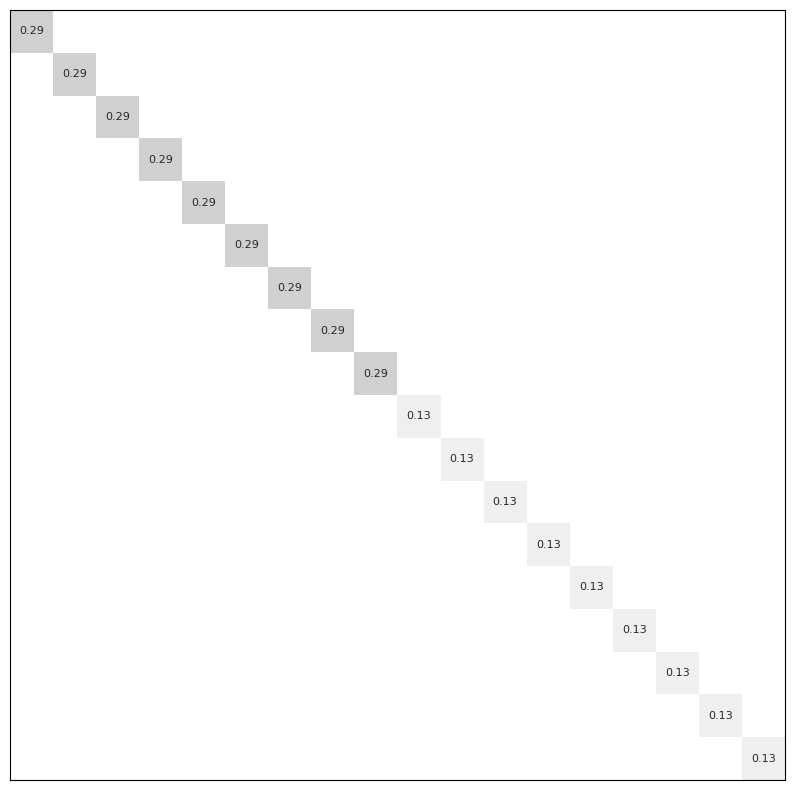

In [44]:
A = np.array((model.lneqs).todense())
n = int(np.prod(model.dims[3:]))

start_row, end_row = 216 + 18, 216 + 18 + 18
start_col, end_col = 540 + 18, 540 + 18 + 18  # 108 216 540
matrix = A[start_row:end_row, start_col:end_col]
annot_labels = np.empty_like(matrix, dtype="<U5")

annot_mask = matrix != 0
matrix[matrix == 0] = np.nan
annot_labels[annot_mask] = matrix[annot_mask].round(2).astype(str)

fig = plt.figure(figsize=(10, 10))
# ax = sns.heatmap(matrix != 0, vmin=0, cmap="afmhot_r", cbar=False, xticklabels=n, yticklabels=n)
ax = sns.heatmap(
    matrix,
    vmax=1,
    # vmin=-1,
    # cmap="RdGy_r",
    vmin=0,
    cmap="Greys",
    cbar=False,
    xticklabels=False,
    yticklabels=False,
    annot=annot_labels,
    fmt="",
    annot_kws={"fontsize": 8},
)
# for i in range(1, 18):
#     ax.hlines(y= i, xmin=0, xmax=18, linewidth=1, color="gray", alpha=0.5)
#     ax.vlines(x= i, ymin=0, ymax=18, linewidth=1, color="gray", alpha=0.5)

for _, spine in ax.spines.items():
    spine.set_visible(True)
# plt.grid(True, alpha=0.5)
plt.savefig("TEST.png", transparent=True, bbox_inches="tight")

In [90]:
108 * np.arange(1, 8)

array([108, 216, 324, 432, 540, 648, 756])

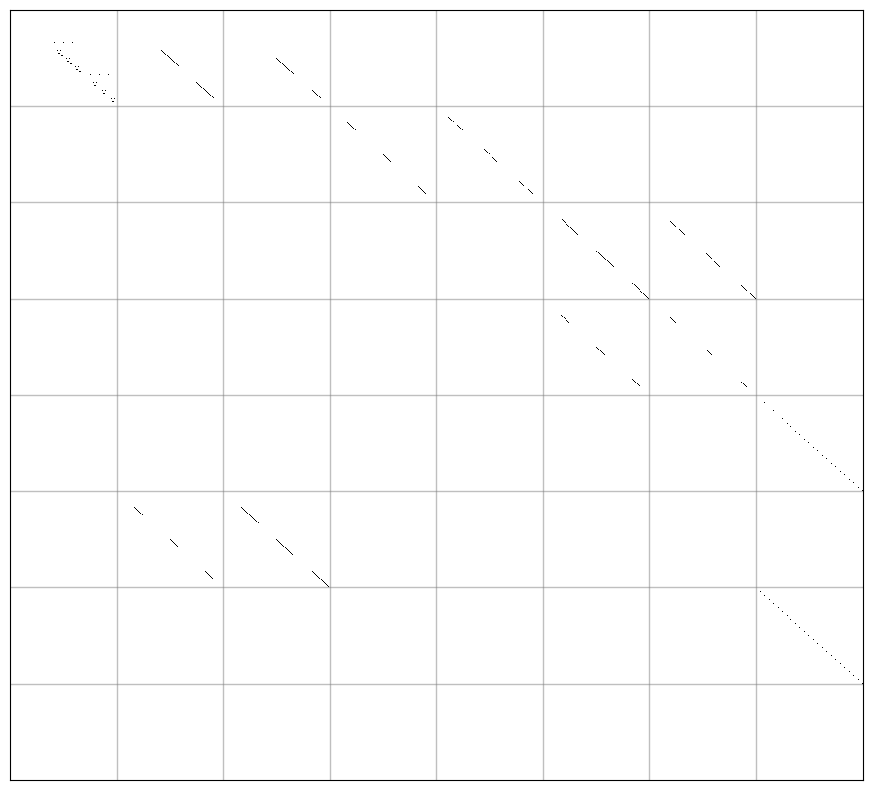

In [43]:
A = np.array((model.lneqs).todense())
n = int(np.prod(model.dims[1:]))

matrix = A
matrix[matrix == 0] = np.nan
matrix[matrix > 0] = 1

fig = plt.figure(figsize=(11, 10))
ax = sns.heatmap(matrix.T, vmin=0, cmap="afmhot_r", cbar=False, xticklabels=False, yticklabels=False)

for _, spine in ax.spines.items():
    spine.set_visible(True)

for i in range(1, 8):
    ax.hlines(y=108 * i, xmin=0, xmax=864, linewidth=1, color="gray", alpha=0.5)
    ax.vlines(x=108 * i, ymin=0, ymax=864, linewidth=1, color="gray", alpha=0.5)

# ax.set_rasterization_zorder(0)
# ax.set_rasterized(True)
# plt.grid(True, alpha=0.7)
plt.savefig("TEST.png", transparent=True, bbox_inches="tight")

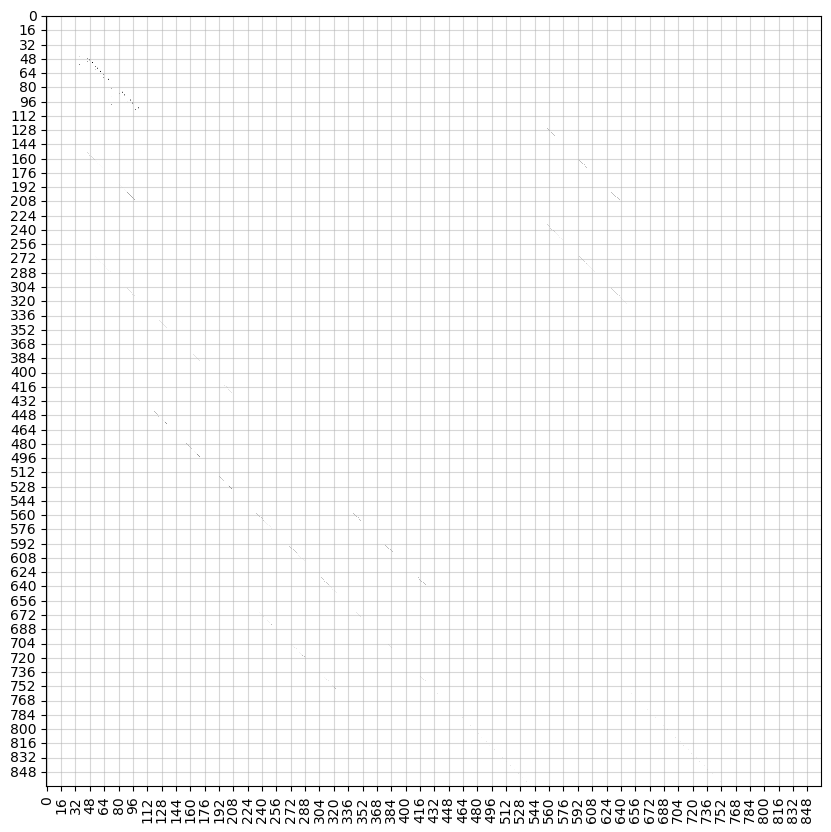

In [25]:
A = np.array((model.lneqs).todense())
n = int(np.prod(model.dims[1:]))

matrix = A
matrix[matrix == 0] = np.nan

fig = plt.figure(figsize=(10, 10))
# ax = sns.heatmap(matrix != 0, vmin=0, cmap="afmhot_r", cbar=False, xticklabels=n, yticklabels=n)
ax = sns.heatmap(
    matrix,
    vmax=1,
    # vmin=-1,
    # cmap="RdGy_r",
    vmin=0,
    cmap="Greys",
    cbar=False,
    # xticklabels=n,
    # yticklabels=n,
    # annot=annot_labels,
    # fmt="",
    # annot_kws={"fontsize": 8},
)
for _, spine in ax.spines.items():
    spine.set_visible(True)
plt.grid(True, alpha=0.5)
# plt.savefig("TEST.png", transparent=True)

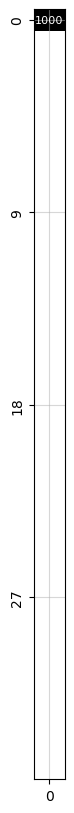

In [98]:
Y = np.array((model.y).todense())
n = int(np.prod(model.dims[3:]))

matrix = Y[36:72]
annot_labels = np.empty_like(matrix, dtype="<U4")
# annot_labels = matrix.astype(str)
annot_mask = matrix > 0
annot_labels[annot_mask] = matrix[annot_mask].round(2).astype(str)

fig = plt.figure(figsize=(0.4, 10))
# ax = sns.heatmap((A != 0).T[36:72,36:72], vmin=0, cmap="afmhot_r", cbar=False, xticklabels=n, yticklabels=n)
ax = sns.heatmap(
    matrix,
    vmin=0,
    cmap="Greys",
    cbar=False,
    xticklabels=n,
    yticklabels=n,
    annot=annot_labels,
    fmt="",
    annot_kws={"fontsize": 8},
)
for _, spine in ax.spines.items():
    spine.set_visible(True)
plt.grid(True, alpha=0.5)

In [58]:
model.dims

(8, 3, 4, 3, 3)

In [6]:
model.size

7039728

In [7]:
model.real_size / model.size

0.5464750910830646

In [240]:
kept_idx = np.sort(model.nnz_idx)
kept_idx

array([ 36,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
        57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
        70,  71,  72,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 153, 154, 155, 156, 157, 158, 159,
       160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 189, 190,
       191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203,
       204, 205, 206, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243,
       244, 245, 246, 247, 248, 249, 250, 251, 270, 271, 272, 273, 274,
       275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287,
       306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318,
       319, 320, 321, 322, 323, 342, 343, 344, 345, 346, 347, 348, 349,
       350, 378, 379, 380, 381, 382, 383, 384, 385, 386, 414, 41

In [ ]:
linalg.spsolve(eye_array(model.real_size) - model.lneqs, model.y)

In [19]:
model.lneqs

<7039728x7039728 sparse matrix of type '<class 'numpy.float64'>'
	with 3309312 stored elements in Compressed Sparse Row format>

In [22]:
# sparsity
(model.lneqs.getnnz() / model.size**2)

6.67768541448321e-08

In [36]:
# non empty rows
1 - (np.diff(model.lneqs.indptr) == 0).sum() / model.size

0.467988535920706

In [50]:
# non empty columns
csc = model.lneqs.tocsc()
1 - (np.diff(csc.indptr) == 0).sum() / model.size

0.1845423573183509

In [54]:
# check using COO
coo = model.lneqs.tocoo()
print(len(np.unique(coo.row)) / model.size)
print(len(np.unique(coo.col)) / model.size)

0.46798853592070605
0.18454235731835095


In [41]:
# indeces of non empty rows
np.arange(model.size)[np.diff(model.lneqs.indptr) == 0]

array([      0,       1,       2, ..., 6715527, 6715528, 6715529])

In [55]:
# indeces of non empty cols
np.arange(model.size)[np.diff(csc.indptr) == 0]

array([      0,       1,       2, ..., 7039725, 7039726, 7039727])

In [49]:
model.size**2

49557770313984

In [12]:
100 * ((model.lneqs.getnnz() + model.size) / model.size**2)

0.1748167438271605

In [241]:
model.sub_systems

({'T1', 'T2', 'T4'}, {'T3'})

In [74]:
source = ["F1", "P1", "C1", "M1", np.nan]
target = ["F8", "P1", "C1", "M1", "E1"]
idx = pd.DataFrame([source, target], columns=model.layer_names)
model.encode_label(idx)
model.ravel_multi_index(idx, model.unravel_coeffs)

array([ 48, 805])

In [78]:
scale = 1e6
max_flow = maximum_flow((scale * model.lneqs).astype(int), 805, 48)
max_flow.flow_value / scale

0.18

In [70]:
sol = model.solve(aggregate=False, pivot=False)
sol.tail(20)

,flow,product,component,material,element,data
160,F7,P1,C3,M1,E2,0.56
161,F7,P1,C3,M2,NaN,2.59
162,F7,P1,C3,M2,E1,0.47
163,F7,P1,C3,M2,E2,2.13
164,F7,P2,C2,M1,NaN,1.66
165,F7,P2,C2,M1,E1,0.76
166,F7,P2,C2,M1,E2,0.89
167,F7,P2,C2,M2,NaN,0.36
168,F7,P2,C2,M2,E1,0.18
169,F7,P2,C2,M2,E2,0.18


In [10]:
L = eye_array(model.size) - model.lneqs
solve = factorized(csc_matrix(L))  # Makes LU decomposition
# arr =   # row vector of shape (model.size, )
# solve(arr) # Uses the LU factors.

<function SuperLU.solve>

In [27]:
vT

array([[ 2.19018350e-32,  1.49618710e-17, -3.78527378e-17, ...,
        -3.33711684e-17,  2.30378387e-19, -1.33133154e-15],
       [-5.76179335e-17,  3.56942073e-30,  4.23281599e-17, ...,
         3.55658210e-17, -2.53071410e-19,  1.16865007e-15],
       [-9.15102515e-18, -1.95809979e-18,  3.52595206e-17, ...,
         5.41488554e-18, -3.72263542e-20, -7.65954175e-16],
       ...,
       [-1.83833081e-17, -6.93889390e-18,  1.27177277e-17, ...,
         1.11528334e-17, -8.19711696e-20,  1.58167111e-17],
       [ 2.02935408e-17,  1.21430643e-17, -1.46938348e-17, ...,
        -1.28538965e-17,  9.07350448e-20, -1.47076391e-17],
       [-6.87460007e-18, -2.99549331e-18,  4.31993526e-18, ...,
         3.80419600e-18, -2.72291288e-20,  2.59416317e-17]])